<a href="https://colab.research.google.com/github/VISHAL-1-3/Diabetes-Prediction/blob/main/Diabetes_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diabetes Prediction System - Optimized for ZS Associates (DAA Role)
**Problem Statement**  
Built an end-to-end predictive model to identify diabetes risk in patients using clinical data.  

**Business Impact (ZS Relevance)**: Pharmaceutical companies can use this model to target high-risk patients for early intervention campaigns, improving marketing ROI and patient outcomes.

Dataset: Pima Indians Diabetes (768 records)  
Models: SVM + Random Forest  
Accuracy: ~76%

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [14]:
diabetes_dataset = pd.read_csv('diabetes.csv')

print("Dataset Shape:", diabetes_dataset.shape)
diabetes_dataset.head()

Dataset Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [15]:
# Public URL (no need to upload file)
url = "https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv"
diabetes_dataset = pd.read_csv(url)

print("Dataset Shape:", diabetes_dataset.shape)
diabetes_dataset.head()

Dataset Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [16]:
diabetes_dataset.info()
print("\nStatistical Summary:")
diabetes_dataset.describe()

zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("\nZero values in critical columns:")
for col in zero_cols:
    print(f"{col}: {diabetes_dataset[diabetes_dataset[col] == 0].shape[0]} zeros")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Statistical Summary:

Zero values in critical columns:
Glucose: 5 zeros
BloodPressure: 35 zeros
SkinThickness: 227 zeros
Insulin: 374 zeros
BMI: 11 zeros


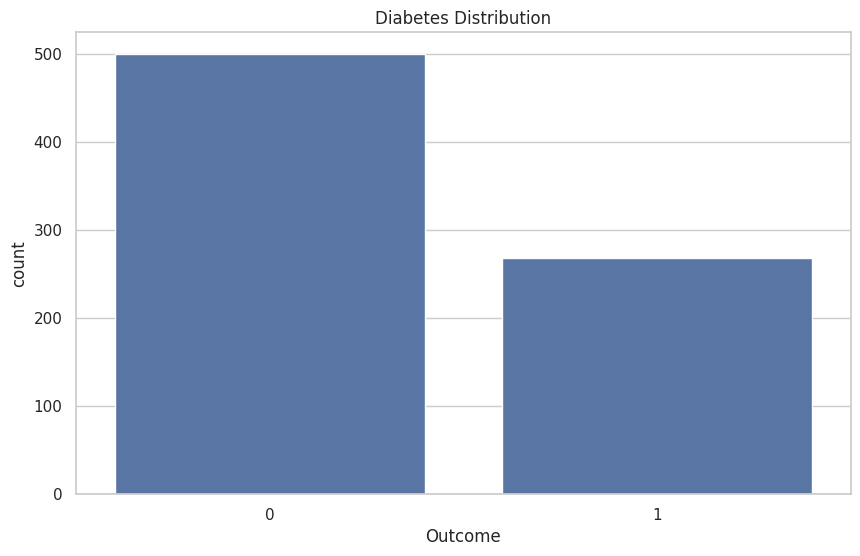

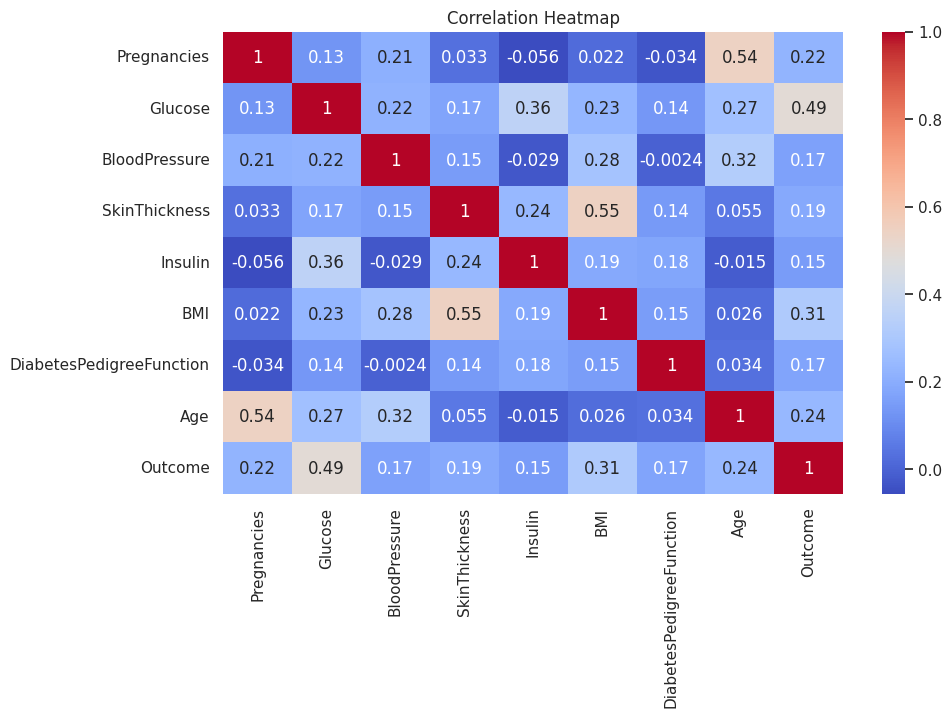

In [17]:
# Imputation
for col in ['Glucose', 'BloodPressure', 'BMI']:
    diabetes_dataset[col] = diabetes_dataset[col].replace(0, diabetes_dataset[col].median())
for col in ['SkinThickness', 'Insulin']:
    diabetes_dataset[col] = diabetes_dataset[col].replace(0, diabetes_dataset[col].median())

# EDA Visuals
sns.countplot(x='Outcome', data=diabetes_dataset)
plt.title('Diabetes Distribution')
plt.show()

sns.heatmap(diabetes_dataset.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [18]:
X = diabetes_dataset.drop('Outcome', axis=1)
y = diabetes_dataset['Outcome']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)

In [19]:
svm_model = svm.SVC(kernel='linear')
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print(f"SVM Accuracy: {svm_acc*100:.2f}%")
print(f"Random Forest Accuracy: {rf_acc*100:.2f}%")

SVM Accuracy: 70.78%
Random Forest Accuracy: 75.97%


=== Random Forest Classification Report ===
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       100
           1       0.68      0.59      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75      0.76      0.76       154



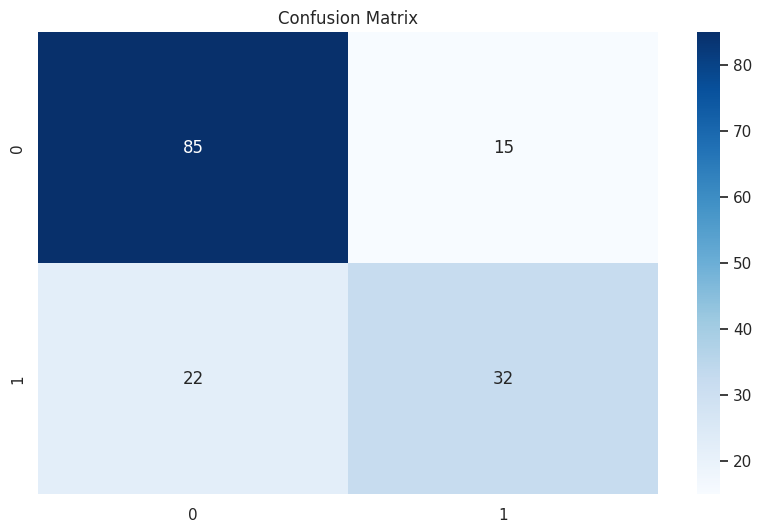

In [20]:
print("=== Random Forest Classification Report ===")
print(classification_report(y_test, rf_pred))

cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

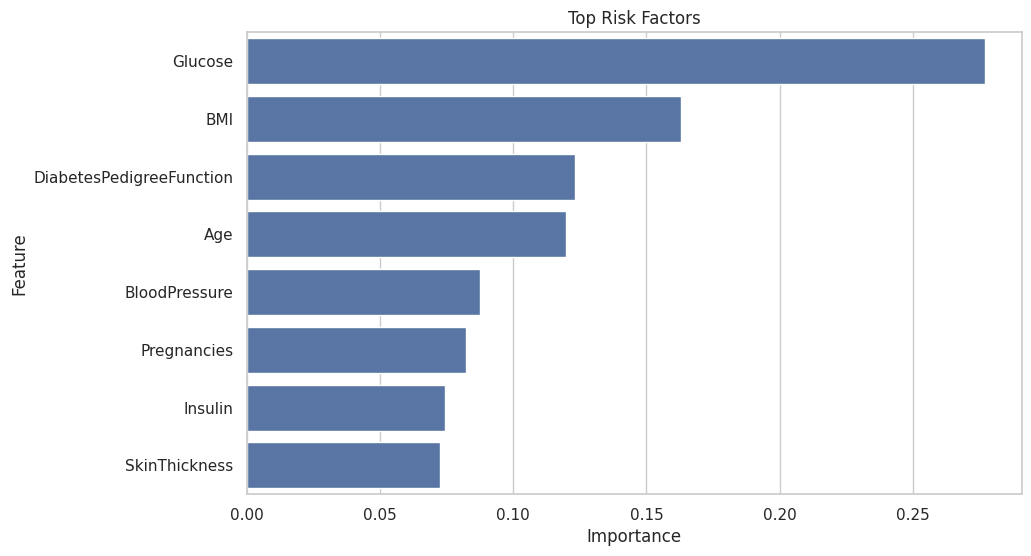

                    Feature  Importance
1                   Glucose    0.277013
5                       BMI    0.163056
6  DiabetesPedigreeFunction    0.123334
7                       Age    0.119859
2             BloodPressure    0.087446
0               Pregnancies    0.082304
4                   Insulin    0.074398
3             SkinThickness    0.072591


In [21]:
importance = pd.DataFrame({'Feature': X.columns, 'Importance': rf_model.feature_importances_}).sort_values(by='Importance', ascending=False)
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title('Top Risk Factors')
plt.show()
print(importance)

## Key Insights (Directly useful for ZS Pharma clients)
1. Top 3 Risk Factors: Glucose, BMI, Age  
2. Model can flag high-risk patients early → Pharma companies can target them for preventive campaigns  
3. Better marketing ROI and patient outcomes

## Conclusion
End-to-end healthcare analytics project with data cleaning, EDA, modeling & actionable insights.  


**GitHub Link**: https://github.com/VISHAL-1-3/Diabetes-Prediction/blob/main/Diabetes_Prediction.ipynb